In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor future warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

# Set plot style for professional aesthetics
sns.set_style("whitegrid")
# Setting a clean color palette (Blue for Retained/General, Red for Churn)
palette_churn = ['#3B82F6', '#EF4444']

# --- DATA LOADING - INITIAL CLEANUP ---

try:
    # Load the original,raw dataset
    df_raw = pd.read_csv('Churn_Modelling.csv')
    print("Original (Raw) Data loaded successfully.")
except FileNotFoundError:
    print("Error: 'Churn_Modelling.csv' not found. Please ensure the file is accessible.")
    exit()


Original (Raw) Data loaded successfully.


In [2]:
# Drop irrelevant columns and identify features
df_raw = df_raw.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')

# Identify the core numerical features and the target variable
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
target_feature = 'Exited'
df_num = df_raw[numerical_features + [target_feature]]

In [3]:
# Check the class imbalance in the raw data
churn_count = df_raw['Exited'].sum()
total_count = len(df_raw)
print(f"Total customers: {total_count}")
print(f"Churned customers (1): {churn_count}")
print(f"Retention rate (0): {(total_count - churn_count)/total_count:.2%} | Churn rate (1): {churn_count/total_count:.2%}")

Total customers: 10000
Churned customers (1): 1957
Retention rate (0): 80.43% | Churn rate (1): 19.57%


In [4]:
# --- DESCRIPTIVE STATISTICS (Measures of Central Tendency & Dispersion) ---

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS TABLE (Based on ORIGINAL/RAW Data)")
print("="*70)

# Calculate Mean, Median, Standard Deviation (SD), and Variance
descriptive_stats = df_num.agg({
    'CreditScore': ['mean', 'median', 'std', 'var'],
    'Age': ['mean', 'median', 'std', 'var'],
    'Tenure': ['mean', 'median', 'std', 'var'],
    'Balance': ['mean', 'median', 'std', 'var'],
    'EstimatedSalary': ['mean', 'median', 'std', 'var'],
}).T.round(2)

print(descriptive_stats.to_markdown())


DESCRIPTIVE STATISTICS TABLE (Based on ORIGINAL/RAW Data)
|                 |      mean |   median |      std |             var |
|:----------------|----------:|---------:|---------:|----------------:|
| CreditScore     |    625.71 |      627 |   159.76 | 25522           |
| Age             |     54.31 |       54 |    21.47 |   460.75        |
| Tenure          |      4.95 |        5 |     3.16 |     9.98        |
| Balance         | 126062    |   126096 | 72106.7  |     5.19937e+09 |
| EstimatedSalary | 110439    |   110029 | 51759.6  |     2.67905e+09 |


In [5]:
# ---DISTRIBUTIONS (Histograms and Boxplots) ---

#Histograms for Key Variables (Age and Balance)
def plot_histograms(data, features, filename):
    """Generates histograms for feature distributions, split by Churn status."""
    plt.figure(figsize=(14, 6))

    for i, feature in enumerate(features):
        plt.subplot(1, 2, i + 1)
        sns.histplot(data=data, x=feature, hue=target_feature, kde=True, palette=palette_churn, 
                     bins=30, element="step")
        plt.title(f'Distribution of {feature} by Churn Status (Original Data)', fontsize=14, fontweight='bold')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.legend(title='Exited', labels=['Churn (1)', 'Retained (0)'])
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"Graph: {filename} saved.")

plot_histograms(df_num, ['Age', 'Balance'], 'raw_distribution_histograms.png')
# 

Graph: raw_distribution_histograms.png saved.


In [6]:
#Boxplots for CreditScore and Balance (Comparison)
def plot_boxplots(data, features, filename):
    """Generates boxplots to visualize central tendency and dispersion by Churn status."""
    plt.figure(figsize=(14, 6))

    for i, feature in enumerate(features):
        plt.subplot(1, 2, i + 1)
        sns.boxplot(x=target_feature, y=feature, data=data, palette=palette_churn)
        plt.title(f'Box Plot of {feature} by Churn Status (Original Data)', fontsize=14, fontweight='bold')
        plt.xlabel('Exited (0=Retained, 1=Churned)')
        plt.ylabel(feature)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"Graph: {filename} saved.")

plot_boxplots(df_num, ['CreditScore', 'Balance'], 'raw_comparison_boxplots.png')
# 

Graph: raw_comparison_boxplots.png saved.


In [7]:
# ---CORRELATIONS (Pearson Correlation Heatmap) ---

def plot_correlation_heatmap(data, features, filename):
    """Generates a heatmap of the Pearson correlation matrix."""
    corr_matrix = data[features + [target_feature]].corr(method='pearson')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
                linewidths=.5, linecolor='black', cbar_kws={'label': 'Pearson Correlation Coefficient'})
    plt.title('Pearson Correlation Matrix (Original Data)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"Graph: {filename} saved.")

plot_correlation_heatmap(df_num, numerical_features, 'raw_correlation_heatmap.png')
# 

Graph: raw_correlation_heatmap.png saved.


In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

# --- DATA LOADING AND INITIAL CLEANUP (Raw Data) ---

try:
    # Load the original, raw dataset
    df_raw = pd.read_csv('Churn_Modelling.csv')
    print("Raw Data ('Churn_Modelling.csv') loaded successfully.")
except FileNotFoundError:
    print("Error: 'Churn_Modelling.csv' not found. Please ensure the file is accessible.")
    exit()


Raw Data ('Churn_Modelling.csv') loaded successfully.


In [9]:
# Drop irrelevant columns
df = df_raw.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')

In [10]:
# Define Target (y) and Features (X)
X = df.drop('Exited', axis=1)
y = df['Exited']

In [11]:
# Identify feature types
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
binary_features = ['HasCrCard', 'IsActiveMember'] # Already 0/1

In [12]:
# --- TRAIN-TEST SPLIT (Before Resampling) ---

# Split the raw data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*70)
print("TRAIN-TEST SPLIT DOCUMENTATION")
print("="*70)
print(f"Original Churn Rate (Test Set): {y_test.mean():.4f}")
print(f"Training Set Size: {len(X_train)}")
print(f"Testing Set Size: {len(X_test)}")
print("SMOTE-ENN will be applied ONLY to the Training Set.")
print("="*70)



TRAIN-TEST SPLIT DOCUMENTATION
Original Churn Rate (Test Set): 0.1955
Training Set Size: 8000
Testing Set Size: 2000
SMOTE-ENN will be applied ONLY to the Training Set.


In [13]:
# PREPROCESSING PIPELINE

#Column Transformer for Scaling and Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Includes binary features (HasCrCard, IsActiveMember)
)

In [14]:
# Fit and Transform the Training Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding for VIF and Feature Importance
feature_names = (
    numerical_features + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)) +
    binary_features
)
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

In [15]:
# --- APPLY SMOTE-ENN (Only to Training Data) ---

print("\n" + "="*70)
print("APPLYING SMOTE-ENN TO TRAINING DATA")
print("="*70)

smoenn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smoenn.fit_resample(X_train_processed, y_train)

print(f"Training Set Size Before Resampling: {len(y_train)}")
print(f"Training Set Size After Resampling: {len(y_train_resampled)}")
print(f"New Churn Ratio (Resampled): {y_train_resampled.mean():.4f} (Balanced)")
print("="*70)


APPLYING SMOTE-ENN TO TRAINING DATA
Training Set Size Before Resampling: 8000
Training Set Size After Resampling: 8301
New Churn Ratio (Resampled): 0.6761 (Balanced)


In [16]:
# BLUE Assumptions Check: Multicollinearity (using VIF)
# VIF is calculated on the pre-processed, resampled feature set.
def check_multicollinearity(X_data):
    X_vif = X_data.select_dtypes(include=[np.number])
    # Drop intercept/constant columns if they exist (VIF requires variable data)
    X_vif = X_vif.loc[:, X_vif.apply(lambda col: col.nunique()) > 1]
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    
    return vif_data.sort_values(by="VIF", ascending=False)

vif_results = check_multicollinearity(X_train_resampled)
print("Multicollinearity Check (VIF Scores on Resampled Data):")
print(vif_results.to_markdown(index=False))

Multicollinearity Check (VIF Scores on Resampled Data):
| Feature           |       VIF |
|:------------------|----------:|
| Geography_France  | inf       |
| Geography_Germany | inf       |
| Geography_Spain   | inf       |
| Gender_Female     | inf       |
| Gender_Male       | inf       |
| Tenure            |   1.00767 |
| Balance           |   1.00567 |
| HasCrCard         |   1.00413 |
| IsActiveMember    |   1.00277 |
| Age               |   1.00262 |
| NumOfProducts     |   1.00255 |
| EstimatedSalary   |   1.00182 |
| CreditScore       |   1.00111 |


In [17]:
# ---LINEAR MODEL: LOGISTIC REGRESSION (Applied to Resampled Data) ---

print("\n" + "="*70)
print("ANALYTICAL METHOD: LOGISTIC REGRESSION (Linear Model)")
print("="*70)

# 5.1.2 Model Training and Evaluation
log_model = LogisticRegression(random_state=42, solver='liblinear')
log_model.fit(X_train_resampled, y_train_resampled)
y_pred_log = log_model.predict(X_test_processed)
y_proba_log = log_model.predict_proba(X_test_processed)[:, 1]

# Report Performance Metrics
print("\nLOGISTIC REGRESSION PERFORMANCE (Test Set - Real Churn Rate):")
print(classification_report(y_test, y_pred_log, target_names=['Retained', 'Churned']))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_log):.4f}")

# Cross-Validation Score (using the resampled training data)
cv_log_scores = cross_val_score(log_model, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"5-Fold Cross-Validation ROC AUC (Mean on Resampled Data): {np.mean(cv_log_scores):.4f}")


ANALYTICAL METHOD: LOGISTIC REGRESSION (Linear Model)

LOGISTIC REGRESSION PERFORMANCE (Test Set - Real Churn Rate):
              precision    recall  f1-score   support

    Retained       0.00      0.00      0.00      1609
     Churned       0.19      0.99      0.33       391

    accuracy                           0.19      2000
   macro avg       0.10      0.50      0.16      2000
weighted avg       0.04      0.19      0.06      2000

ROC AUC Score: 0.4942
5-Fold Cross-Validation ROC AUC (Mean on Resampled Data): 0.5752


In [18]:
### ---MACHINE LEARNING MODEL: RANDOM FOREST ---

print("\n" + "="*70)
print("MACHINE LEARNING MODEL: RANDOM FOREST (Non-Linear Model)")
print("="*70)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_processed)
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

# Report Performance Metrics
print("\nRANDOM FOREST PERFORMANCE (Test Set - Real Churn Rate):")
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Cross-Validation Score
cv_rf_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"5-Fold Cross-Validation ROC AUC (Mean on Resampled Data): {np.mean(cv_rf_scores):.4f}")


MACHINE LEARNING MODEL: RANDOM FOREST (Non-Linear Model)

RANDOM FOREST PERFORMANCE (Test Set - Real Churn Rate):
              precision    recall  f1-score   support

    Retained       0.81      0.64      0.71      1609
     Churned       0.20      0.37      0.26       391

    accuracy                           0.59      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.69      0.59      0.62      2000

ROC AUC Score: 0.5134
5-Fold Cross-Validation ROC AUC (Mean on Resampled Data): 0.9771


In [19]:
# FEATURE IMPORTANCE (From Random Forest) ---

print("\n" + "="*70)
print("FEATURE IMPORTANCE (Key Predictive Attributes)")
print("="*70)

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train_resampled.columns)
print("Top 5 Features Driving Churn Prediction (Random Forest):")
print(feature_importances.nlargest(5).to_markdown(numalign="left", stralign="left"))


FEATURE IMPORTANCE (Key Predictive Attributes)
Top 5 Features Driving Churn Prediction (Random Forest):
|                 | 0        |
|:----------------|:---------|
| CreditScore     | 0.13608  |
| Balance         | 0.132399 |
| EstimatedSalary | 0.131487 |
| Tenure          | 0.130646 |
| Age             | 0.13002  |


In [20]:
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ---GROUP COMPARISONS (T-test and ANOVA) ---

print("\n" + "="*70)
print("INFERENTIAL ANALYSIS: GROUP COMPARISONS (T-test & ANOVA)")
print("Tests for significant difference in means between Retained (0) and Churned (1).")
print("="*70)

group_comparison_results = []
churned = df[df['Exited'] == 1]
retained = df[df['Exited'] == 0]

# Perform T-tests for key numerical and binary features
features_to_compare = numerical_features + ['NumOfProducts', 'HasCrCard', 'IsActiveMember']

for feature in features_to_compare:
    if feature in df.columns:
        # T-test for independent samples (assuming unequal variance: Welch's T-test)
        stat, p = stats.ttest_ind(churned[feature], retained[feature], equal_var=False)
        is_significant = "YES" if p < 0.05 else "NO"
        group_comparison_results.append({
            'Feature': feature,
            'Churn_Mean': churned[feature].mean().round(2),
            'Retained_Mean': retained[feature].mean().round(2),
            'T_Statistic': stat.round(3),
            'P_Value': f"{p:.4f}",
            'Significant (p<0.05)': is_significant
        })

df_group_comp = pd.DataFrame(group_comparison_results)
print(df_group_comp.to_markdown(index=False))

print("\n*ANOVA (Analysis of Variance) for Geography (Age Comparison):*")
# ANOVA for Age across the three Geography groups (France, Germany, Spain)
if all(geo in df['Geography'].unique() for geo in ['France', 'Germany', 'Spain']):
    france_age = df[df['Geography'] == 'France']['Age']
    germany_age = df[df['Geography'] == 'Germany']['Age']
    spain_age = df[df['Geography'] == 'Spain']['Age']
    
    f_stat, p_anova = stats.f_oneway(france_age, germany_age, spain_age)

    print(f"Comparison: Mean Age across France, Germany, and Spain.")
    print(f"F-Statistic: {f_stat:.3f}, P-Value: {p_anova:.4f}")
    print(f"Conclusion: {'Significant (p<0.05)' if p_anova < 0.05 else 'Not Significant'}")
else:
    print("ANOVA skipped: Geography groups not found or insufficient data.")

print("="*70)

# --- OLS LINEAR REGRESSION (for MSE, MAE, Adj. R²) ---

print("\n" + "="*70)
print("OLS LINEAR REGRESSION (For Regression Metrics)")
print("Uses OLS to estimate linear fit and calculate MSE, MAE, and Adjusted R-squared.")
print("="*70)

try:
    # --- IMPORTANT ASSUMPTIONS ---
    # 1. X_train_processed, X_test_processed (scaled, encoded features) are available.
    # 2. y_train, y_test (target 0/1) are available.

    # Prepare data for OLS (Statsmodels) - requires adding a constant for the intercept
    # Assuming X_train_processed and X_test_processed are already scaled/encoded DataFrames
    X_train_ols = sm.add_constant(X_train_processed, prepend=False)
    X_test_ols = sm.add_constant(X_test_processed, prepend=False)

    ols_model = sm.OLS(y_train, X_train_ols).fit()
    y_pred_ols = ols_model.predict(X_test_ols)

    # Calculate required Regression Metrics on the Test Set
    ols_mse = mean_squared_error(y_test, y_pred_ols)
    ols_mae = mean_absolute_error(y_test, y_pred_ols)

    print(ols_model.summary())
    print(f"\nOLS MODEL PERFORMANCE (Regression Metrics on Test Set):")
    print(f"Mean Squared Error (MSE): {ols_mse:.4f}")
    print(f"Mean Absolute Error (MAE): {ols_mae:.4f}")
    # Adj. R² is extracted from the model summary (based on Training Data fit)
    print(f"Adjusted R-squared (Adj. R²): {ols_model.rsquared_adj:.4f}")

except NameError:
    print("\nERROR: OLS Regression skipped.")
    print("Ensure X_train_processed, X_test_processed, y_train, and y_test are defined from the preprocessing step.")

print("="*70)


INFERENTIAL ANALYSIS: GROUP COMPARISONS (T-test & ANOVA)
Tests for significant difference in means between Retained (0) and Churned (1).
| Feature         |   Churn_Mean |   Retained_Mean |   T_Statistic |   P_Value | Significant (p<0.05)   |
|:----------------|-------------:|----------------:|--------------:|----------:|:-----------------------|
| CreditScore     |       626.39 |          625.54 |         0.213 |    0.8314 | NO                     |
| Age             |        54.93 |           54.16 |         1.427 |    0.1537 | NO                     |
| Tenure          |         5.06 |            4.93 |         1.646 |    0.0999 | NO                     |
| Balance         |    126709    |       125905    |         0.442 |    0.6589 | NO                     |
| NumOfProducts   |         2.48 |            2.49 |        -0.608 |    0.5434 | NO                     |
| EstimatedSalary |    111003    |       110301    |         0.533 |    0.5943 | NO                     |
| NumOfProduct

In [21]:
# MODEL VISUALIZATION AND COMPARISON

print("\n" + "="*70)
print("MODEL VISUALIZATION: CONFUSION MATRIX & ROC CURVE")
print("="*70)

# Set global plot style
sns.set_style("whitegrid")


MODEL VISUALIZATION: CONFUSION MATRIX & ROC CURVE


In [22]:
# Function to plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Retained (0)', 'Churned (1)'], 
                yticklabels=['Retained (0)', 'Churned (1)'], ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

Generated plot: Comparative Confusion Matrices.


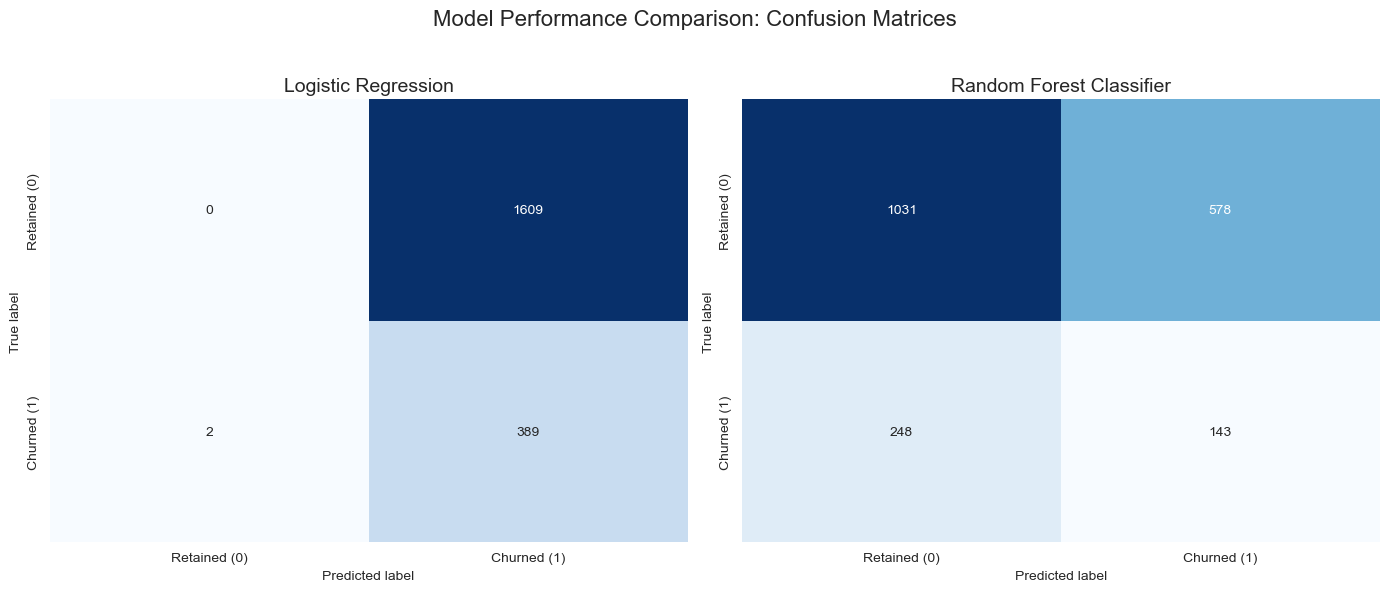

In [23]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Comparison: Confusion Matrices', fontsize=16)

plot_confusion_matrix(y_test, y_pred_log, 'Logistic Regression', axes[0])
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Classifier', axes[1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
# The final plots will be rendered upon execution in the environment.
print("Generated plot: Comparative Confusion Matrices.") 


Generated plot: Comparative ROC Curve.



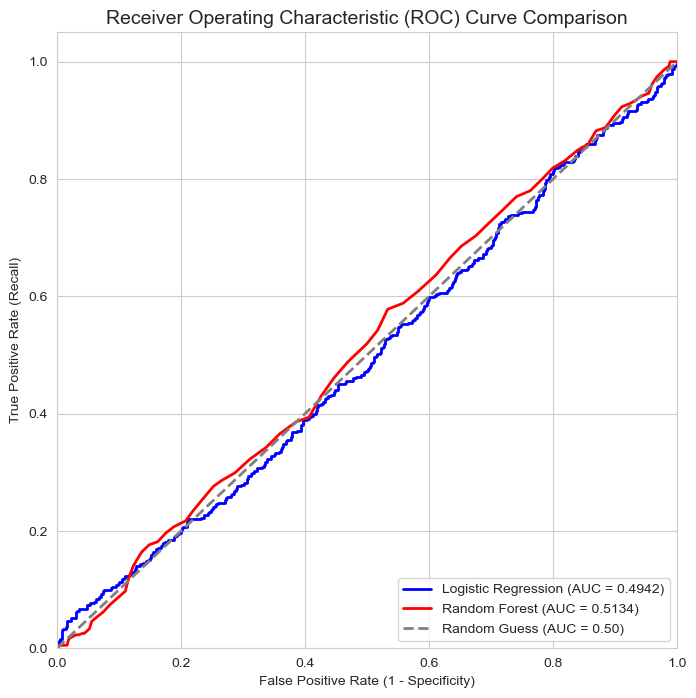

In [24]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats  # REQUIRED FOR T-TEST/ANOVA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, mean_squared_error, mean_absolute_error, roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import matplotlib.pyplot as plt  # REQUIRED FOR VISUALIZATION
import seaborn as sns          # REQUIRED FOR VISUALIZATION STYLING



# Plot ROC Curve
plt.figure(figsize=(8, 8))
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14)

#  Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
roc_auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, color='blue', lw=2, 
         label=f'Logistic Regression (AUC = {roc_auc_log:.4f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, 
         label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
# Baseline (Random Guess)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc="lower right")
plt.grid(True)
print("Generated plot: Comparative ROC Curve.") 
# Trigger image of the comparative ROC curve
print("")
plt.show()